# Equivariant Convolution Homework

This notebook contains two tasks for building and verifying rotation-equivariant convolutions. The focus is on `Z2P4Conv2d` and `P4P4Conv2d` implementations.

**Goal:** implement both group-aware convolution layers and then verify them visually.

## Task 1: Implement `Z2P4Conv2d` and `P4P4Conv2d` (50 P)

You should implement two layer classes:

1. `Z2P4Conv2d`
   - Input shape: `[B, in_channels, H, W]`
   - The layer should build a filter bank for the 4 rotations of the base kernel: `0°`, `90°`, `180°`, `270°`.
   - If the base filter has shape `[out_channels, in_channels, k, k]`, the rotated filter bank should have shape `[out_channels*4, in_channels, k, k]`.
   - Use `torch.rot90` to rotate the base weight and then concatenate the rotated copies before applying `F.conv2d`.

2. `P4P4Conv2d`
   - This layer accepts inputs with an internal group structure: `[B, in_channels*4, H, W]`.
   - There are two equivalent implementation variants, choose the one you prefer:
     - **Variant A: flattened group dimension inside channels**
       - Weight shape: `[out_channels, in_channels*4, k, k]`
       - To build the rotated kernels, rotate the base weight spatially and then use `torch.roll(..., shifts=in_channels, dims=1)` so that channel blocks move correctly across the 4 orientation groups.
       - After creating the `90°`, `180°`, and `270°` filtered copies, concatenate them to get `[out_channels*4, in_channels*4, k, k]`.
     - **Variant B: explicit extra group dimension**
       - Weight shape: `[out_channels, in_channels, 4, k, k]`
       - Here the orientation group is explicit in the weight tensor.
       - For a rotation by `r*90°`, rotate each spatial kernel by `r` and cyclically shift the orientation axis by `r`.
       - Stack those transformed weight tensors and reshape to `[out_channels*4, in_channels*4, k, k]` before applying `F.conv2d`.

Write your layers in the code cell below. You can choose to implement both variants as separate classes, or keep one class and use comments to describe the alternative.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Z2P4Conv2d(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 padding=0,
                 stride=1,
                 use_bias=True):
        super().__init__()
        self.weight = nn.Parameter(
            torch.randn(out_channels, in_channels, kernel_size, kernel_size) *
            .1)
        self.padding = padding
        self.stride = stride
        if use_bias:
            self.bias = nn.Parameter(torch.zeros(out_channels))
        else:
            self.bias = None

    def forward(self, x):
        # TODO: rotate self.weight by 0°, 90°, 180°, 270° and concatenate them.
        # Use F.conv2d to apply `self.weight` to `x`
        # The result should have shape [out_channels*4, in_channels, kernel_size, kernel_size].
        r0 = torch.rot90(self.weight, 0, (2, 3))
        r90 = torch.rot90(self.weight, 1, (2, 3))
        r180 = torch.rot90(self.weight, 2, (2, 3))
        r270 = torch.rot90(self.weight, 3, (2, 3))
        W = torch.cat([r0, r90, r180, r270])
        return F.conv2d(x, W, bias=self.bias.repeat(4), stride=self.stride, padding=self.padding)



class P4P4Conv2d(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 padding=0,
                 stride=1,
                 use_bias=True):
        super().__init__()
        self.weight = nn.Parameter(
            torch.randn(out_channels, in_channels * 4, kernel_size,
                        kernel_size) * .1)
        self.padding = padding
        self.stride = stride
        if use_bias:
            self.bias = nn.Parameter(torch.zeros(out_channels))
        else:
            self.bias = None

    def forward(self, x):
        # TODO: this layer receives an input of shape [B, in_channels*4, H, W].
        # Use torch.rot90 to rotate kernels spatially and torch.roll to shift kernels along the group dimension.
        in_channels = self.weight.shape[1] // 4
        filters = []
        
        for i in range(4):
            w_rot = torch.rot90(self.weight, k=i, dims=[2, 3])
            w_rolled = torch.roll(w_rot, shifts=i * in_channels, dims=1)
            filters.append(w_rolled)
            
        weight_p4 = torch.cat(filters, dim=0)
        
        bias_p4 = None
        if self.bias is not None:
            bias_p4 = self.bias.repeat(4)
            
        return F.conv2d(x.repeat(1, 4, 1, 1), weight_p4, bias=bias_p4, padding=self.padding, stride=self.stride).squeeze(0)

## Task 2: Verification and visualization (10 P)

Use the cell below to verify your implementation.

- Instantiate `Z2P4Conv2d` with 1 input and 2 output channels, and `P4P4Conv2d` with 2 input and 4 output channels.
- Create a random input image and a rotated version of it.
- Compute outputs from both the original and rotated inputs.
- Rotate the feature maps of the rotated images back to match the original orientation.
- Plot feature maps side-by-side and compare pairwise channel distances. Use the provided functions `plot_feature_maps_pair` and `plot_pairwise_distances`

If the implementation is correct, the rotated output should align with the original output after the appropriate channel roll and spatial rotation. The pairwise distance matrix should show near-zero distance along the correct correspondences.

In [17]:
# Utility functions

import matplotlib.pyplot as plt


def plot_feature_maps_pair(fmaps_a, fmaps_b, title, row1_label, row2_label):
    n_channels = fmaps_a.shape[1]
    n_cols = n_channels
    n_rows = 2
    fig, axs = plt.subplots(n_rows,
                            n_cols,
                            figsize=(n_cols * 1.5, n_rows * 1.3),
                            squeeze=False)
    fig.suptitle(title)
    for i in range(n_channels):
        axs[0, i].imshow(fmaps_a[0, i].detach().cpu(), cmap="magma")
        axs[0, i].set_xticklabels([])
        axs[0, i].set_yticklabels([])
        axs[0, i].set_xticks([])
        axs[0, i].set_yticks([])

        axs[1, i].imshow(fmaps_b[0, i].detach().cpu(), cmap="magma")
        axs[1, i].set_xticklabels([])
        axs[1, i].set_yticklabels([])
        axs[1, i].set_xticks([])
        axs[1, i].set_yticks([])

    plt.tight_layout()

    axs[0, 0].set_ylabel(row1_label, rotation=0, labelpad=7, ha="right")
    axs[1, 0].set_ylabel(row2_label, rotation=0, labelpad=7, ha="right")

    
    plt.show()


def plot_pairwise_distances(tensor1,
                            tensor2,
                            title="Pairwise Distance Matrix"):
    B, C, H, W = tensor1.shape
    t1 = tensor1.reshape(B, C, -1)
    t2 = tensor2.reshape(B, C, -1)
    distances = t1[:, :, None, :] - t2[:, None, :, :]
    distances = torch.norm(distances, p=2, dim=-1)
    plt.figure(figsize=(7, 6))
    plt.imshow(distances[0].cpu().numpy(), cmap="magma", aspect="auto")
    plt.colorbar(label="L2 Distance")
    plt.xlabel("Channels")
    plt.ylabel("Channels")
    plt.title(title)
    plt.tight_layout()
    plt.show()

torch.Size([1, 8, 8, 8]) torch.Size([1, 8, 8, 8])


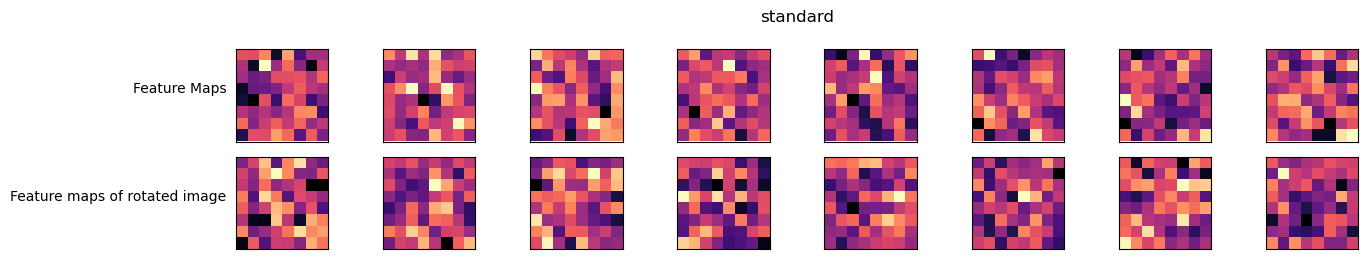

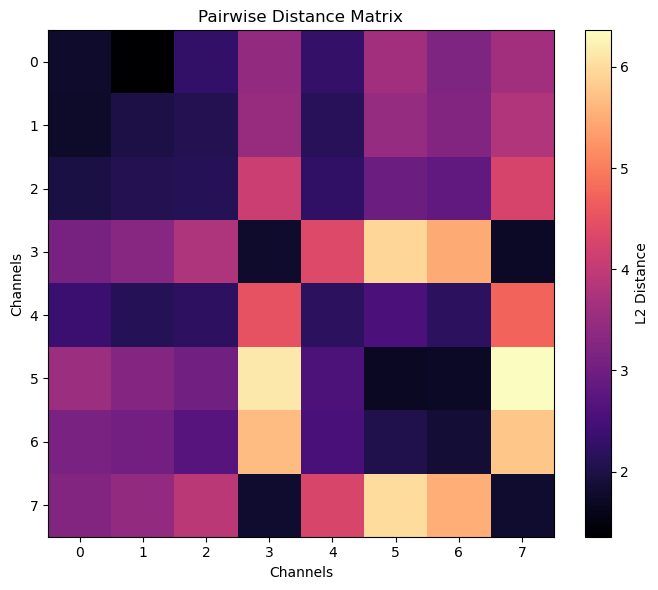

torch.Size([1, 16, 8, 8]) torch.Size([1, 16, 8, 8])


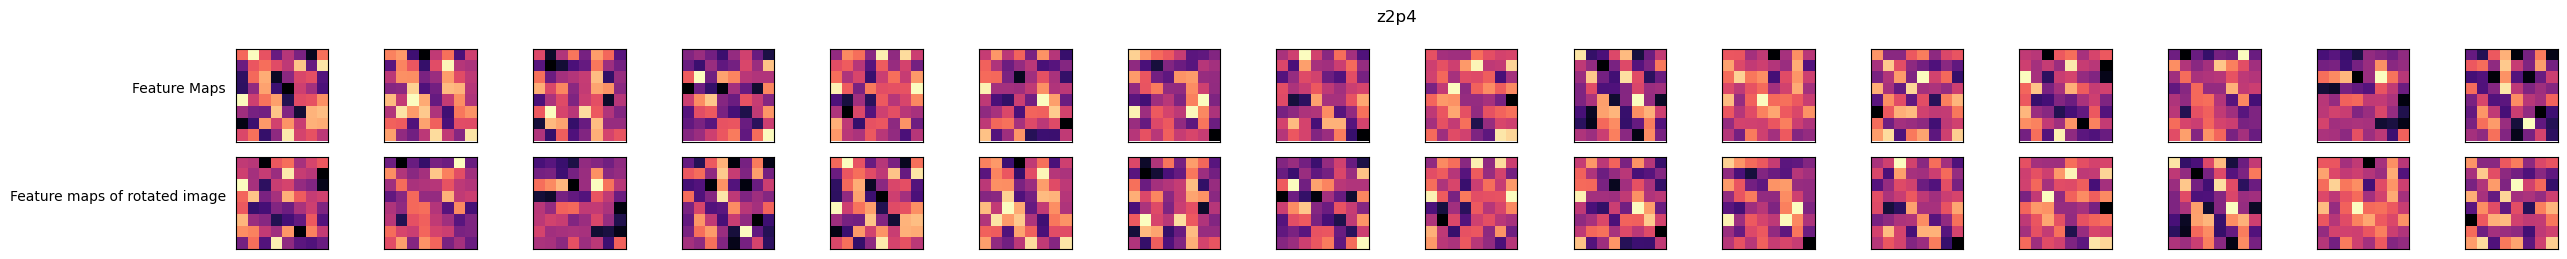

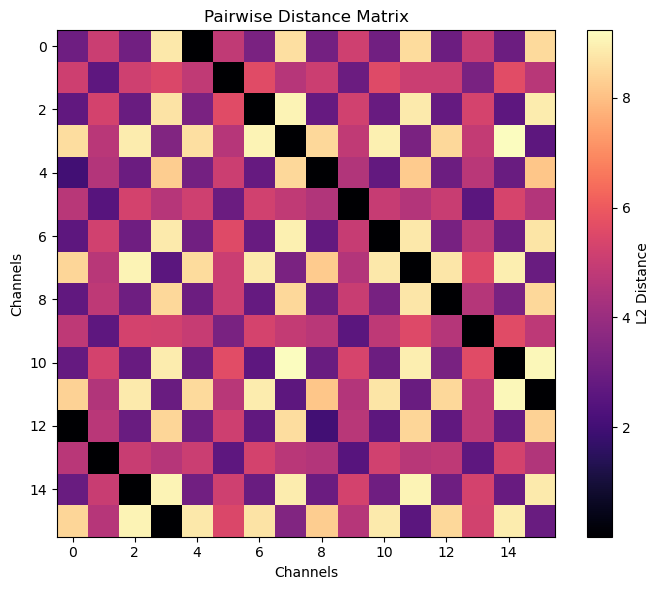

torch.Size([1, 16, 8, 8]) torch.Size([1, 16, 8, 8])


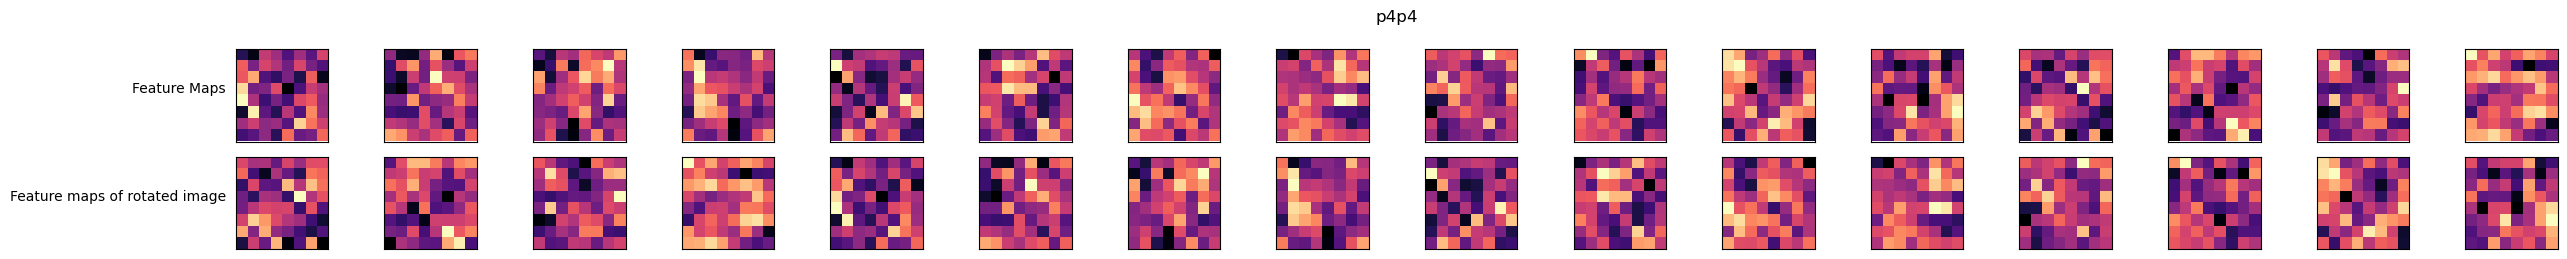

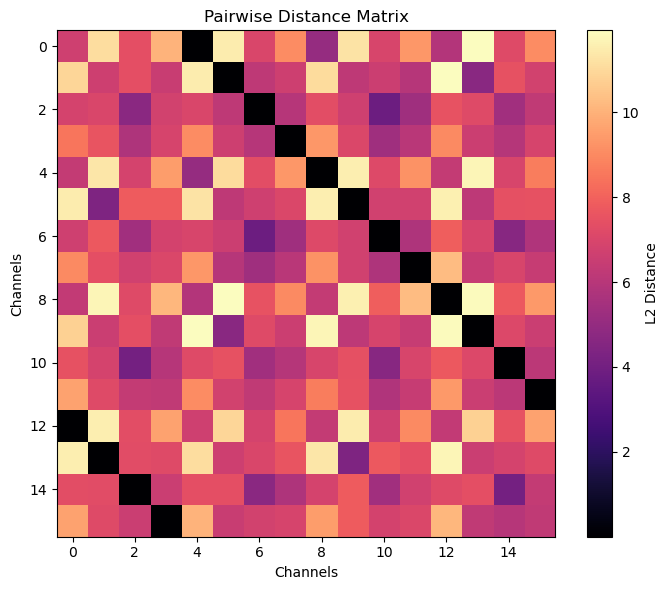

In [18]:
# TODO: instantiate standard, z2p4 and p4p4 conv layers
kernel_size = 8
standard = torch.nn.Conv2d(1, 8, kernel_size) 
z2p4 = Z2P4Conv2d(1, 4, kernel_size)
p4p4 = P4P4Conv2d(1, 4, kernel_size)

# TODO: create a random image and its 90° rotated version
image = torch.rand(1, 15, 15)
image_rot = torch.rot90(image, 1, dims=(-2,-1))

# TODO: feed the images first through the Z2P4Conv2d, then to the P4P4Conv2d layers
layers = [standard, z2p4, p4p4]
names = ['standard', 'z2p4', 'p4p4']
for layer, name in zip(layers, names):
    im = layer(image).unsqueeze(0).detach()
    rim = torch.rot90(layer(image_rot), -1, (-2, -1)).unsqueeze(0).detach()
    print(im.shape, rim.shape)
    plot_feature_maps_pair(im, rim, name, 'Feature Maps', 'Feature maps of rotated image')
    plot_pairwise_distances(im, rim)